# Computer Exercise 2.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.2 Gaussian Elimination with Scaled Partial Pivoting
> **풀이 일자**: Day 09
> **언어**: Python 3 (NumPy / mpmath / Matplotlib)


## 1. 문제 (원문)

> **3.** Solve $H_n \mathbf{x} = \mathbf{b}$ for the Hilbert matrix $H_{ij} = 1/(i+j-1)$, $i,j = 1,\ldots,n$, with
> $n \in \{5, 8, 10, 12, 15\}$, using (a) naïve Gaussian elimination, (b) Gaussian elimination with
> scaled partial pivoting, and (c) `np.linalg.solve`. Generate $\mathbf{b}$ in extended precision so that the
> exact solution $\mathbf{x}^* = (1,\ldots,1)$ is known. Compare residuals, forward errors, and assess whether
> SPP **helps** in this ill-conditioned case.

### 한국어 풀이용 정리
§2.1 Problem 3 에서 Hilbert 의 *극심한 조건수* 가 오차를 폭발시키는 것을 봤다.
오늘 묻는 것은: **SPP 가 그것을 살릴 수 있는가?**

답은 — Problem 2 에서 이미 암시됐듯이 — **아니다, 본질적으로 못 살린다**. SPP 는 *알고리즘 안정성*
을 보장할 뿐, *문제 조건수* 자체를 바꾸지는 못한다. 다만 어떤 측면에서 어떻게 차이가 나는지 정밀
하게 본다.


## 2. 수학적 배경

### 2.1 Hilbert 행렬
$H_n$ 은 양정치 대칭 행렬이지만 조건수가 지수적으로 폭발한다:

$$
\kappa_2(H_n) \;\sim\; \frac{(1+\sqrt{2})^{4n}}{\sqrt{n}} \;\approx\; 10^{1.5 n}.
$$

$n = 12$ 면 $\kappa \approx 10^{16}$, 즉 배정도의 정밀도와 정확히 겹친다.

### 2.2 SPP 의 한계
Problem 2 에서 확인한 대로

$$
\frac{\|\hat{\mathbf{x}} - \mathbf{x}^*\|}{\|\mathbf{x}^*\|} \;\lesssim\; \kappa(H_n) \cdot \varepsilon_{\text{mach}}.
$$

알고리즘이 무엇이든 이 한계는 깨지지 않는다. SPP 의 효과는 *행 스케일* 에서 오는데, $H_n$ 은 이미
행 스케일이 비교적 일정 (행 합이 $\sim \log n$) 해서 *행 사이의 상대 크기 문제* 가 없다. 따라서

$$
\boxed{\;\text{Hilbert 에서 naïve 와 SPP 의 차이는 작다 (둘 다 본질적 한계에 묶인다).}\;}
$$

### 2.3 그래도 *작은* 차이는 있다
- naïve 는 first pivot 이 $H_{11} = 1$ 로 충분히 크지만, 소거 후 *Schur complement* 안에서
  점점 작은 값이 누적된다.
- SPP 는 *각 단계마다* 최선의 행을 선택해 growth factor 를 살짝 줄인다.
- 이 차이는 보통 **2~3 배** 수준 — 오차 자릿수를 바꾸지는 못해도 *어느 자릿수까지 신뢰 가능한가*
  에서 의미가 있다.


## 3. 풀이 흐름

1. `naive_gauss`, `spp_gauss` (Problem 1 의 것을 그대로).
2. $n \in \{5, 8, 10, 12, 15\}$ 에 대해 Hilbert $H_n$ 생성.
3. `mpmath` 50자리로 $\mathbf{b} = H_n \cdot \mathbf{1}$ 을 정확히 계산 → float 로 다운캐스트.
4. 세 알고리즘으로 $\hat{\mathbf{x}}$ 계산.
5. 잔차 $\|H_n \hat{\mathbf{x}} - \mathbf{b}\|_\infty$, 오차 $\|\hat{\mathbf{x}} - \mathbf{1}\|_\infty$ 측정.
6. 이론선 $\kappa(H_n) \varepsilon_{\text{mach}}$ 와 함께 시각화.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpmath as mp


def naive_gauss(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    for k in range(n - 1):
        if A[k, k] == 0.0:
            raise ZeroDivisionError(f"zero pivot at step {k}")
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] -= m * A[k, k:]
            b[i]     -= m * b[k]
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - A[i, i+1:] @ x[i+1:]) / A[i, i]
    return x


def spp_gauss(A, b):
    A = np.array(A, dtype=float, copy=True)
    b = np.array(b, dtype=float, copy=True)
    n = A.shape[0]
    l = np.arange(n)
    s = np.max(np.abs(A), axis=1)
    if np.any(s == 0):
        raise ValueError("singular row")
    for k in range(n - 1):
        ratios = np.abs(A[l[k:], k]) / s[l[k:]]
        p = k + int(np.argmax(ratios))
        l[k], l[p] = l[p], l[k]
        pivot = A[l[k], k]
        if pivot == 0.0:
            raise ZeroDivisionError(f"zero pivot at step {k}")
        for i in range(k + 1, n):
            m = A[l[i], k] / pivot
            A[l[i], k:] -= m * A[l[k], k:]
            b[l[i]]     -= m * b[l[k]]
    x = np.zeros(n)
    x[n-1] = b[l[n-1]] / A[l[n-1], n-1]
    for i in range(n - 2, -1, -1):
        x[i] = (b[l[i]] - A[l[i], i+1:] @ x[i+1:]) / A[l[i], i]
    return x


def hilbert(n):
    return np.array([[1.0/(i+j+1) for j in range(n)] for i in range(n)])


def hilbert_b_exact(n, mp_prec=50):
    mp.mp.dps = mp_prec
    b = []
    for i in range(1, n + 1):
        s = mp.mpf(0)
        for j in range(1, n + 1):
            s += mp.mpf(1) / mp.mpf(i + j - 1)
        b.append(s)
    return np.array([float(v) for v in b])


In [2]:
eps_mach = np.finfo(float).eps

records = []
for n in [5, 8, 10, 12, 15]:
    H = hilbert(n)
    b = hilbert_b_exact(n)
    x_star = np.ones(n)

    try:
        x_nv = naive_gauss(H, b)
    except Exception:
        x_nv = np.full(n, np.nan)
    x_sp = spp_gauss(H, b)
    x_np = np.linalg.solve(H, b)

    kappa = np.linalg.cond(H)

    def res(x): return np.linalg.norm(H @ x - b, ord=np.inf)
    def err(x): return np.linalg.norm(x - x_star, ord=np.inf)

    records.append({
        "n":            n,
        "kappa(H)":     kappa,
        "naive res":    res(x_nv) if np.all(np.isfinite(x_nv)) else np.nan,
        "spp   res":    res(x_sp),
        "numpy res":    res(x_np),
        "naive err":    err(x_nv) if np.all(np.isfinite(x_nv)) else np.nan,
        "spp   err":    err(x_sp),
        "numpy err":    err(x_np),
        "k*eps":        kappa * eps_mach,
    })

df = pd.DataFrame(records)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
print("Hilbert matrix:  three algorithms compared")
print(df.to_string(index=False))


Hilbert matrix:  three algorithms compared
 n  kappa(H)  naive res  spp   res  numpy res  naive err  spp   err  numpy err     k*eps
 5 4.766e+05  1.110e-16  4.441e-16  2.220e-16  2.591e-12  7.999e-12  2.091e-12 1.058e-10
 8 1.526e+10  4.441e-16  2.220e-16  2.220e-16  2.523e-07  2.725e-07  6.532e-07 3.388e-06
10 1.602e+13  4.441e-16  4.441e-16  4.441e-16  6.028e-04  8.242e-04  5.848e-04 3.558e-03
12 1.643e+16  4.441e-16  4.441e-16  2.220e-16  8.669e-02  6.908e-02  6.480e-01 3.647e+00
15 3.366e+17  4.441e-16  2.220e-16  1.554e-14  7.378e+00  7.882e+00  9.947e+02 7.474e+01


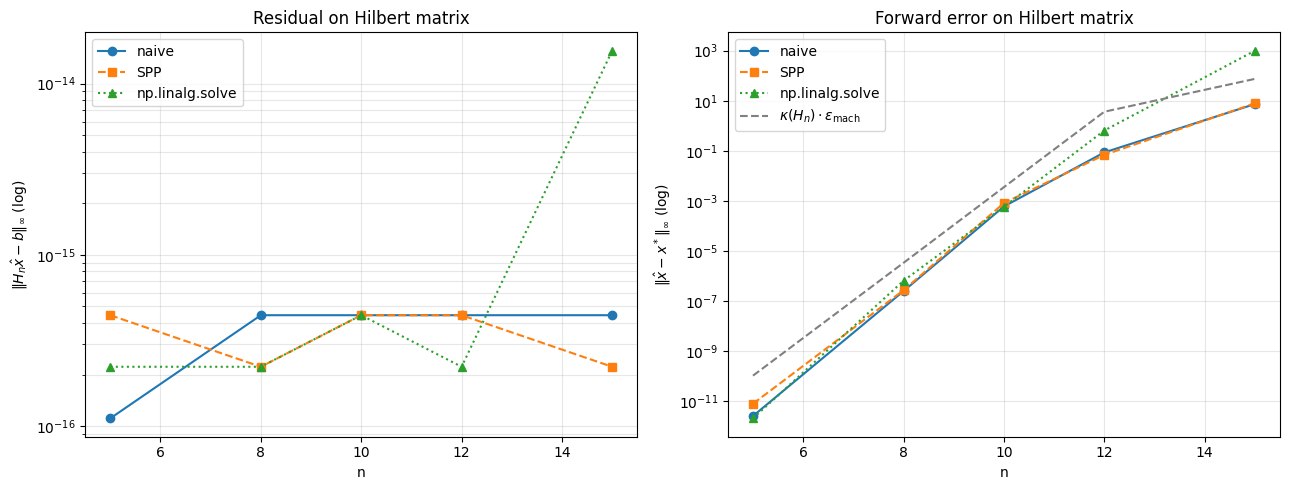

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(df["n"], df["naive res"], "o-",  label="naive")
ax.semilogy(df["n"], df["spp   res"], "s--", label="SPP")
ax.semilogy(df["n"], df["numpy res"], "^:",  label="np.linalg.solve")
ax.set_xlabel("n")
ax.set_ylabel(r"$\|H_n\hat{x}-b\|_\infty$ (log)")
ax.set_title("Residual on Hilbert matrix")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

ax = axes[1]
ax.semilogy(df["n"], df["naive err"], "o-",  label="naive")
ax.semilogy(df["n"], df["spp   err"], "s--", label="SPP")
ax.semilogy(df["n"], df["numpy err"], "^:",  label="np.linalg.solve")
ax.semilogy(df["n"], df["k*eps"],     "--", color="gray", label=r"$\kappa(H_n)\cdot\varepsilon_{\mathrm{mach}}$")
ax.set_xlabel("n")
ax.set_ylabel(r"$\|\hat{x}-x^*\|_\infty$ (log)")
ax.set_title("Forward error on Hilbert matrix")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


In [4]:
# How much does SPP help over naive on Hilbert?
df_help = pd.DataFrame({
    "n":                  df["n"],
    "kappa":              df["kappa(H)"],
    "err_naive/err_spp":  df["naive err"] / df["spp   err"],
    "err_spp/err_numpy":  df["spp   err"] / df["numpy err"],
})
print("Ratios (>1 means SPP / NumPy were better)")
print(df_help.to_string(index=False))


Ratios (>1 means SPP / NumPy were better)
 n     kappa  err_naive/err_spp  err_spp/err_numpy
 5 4.766e+05          3.239e-01          3.825e+00
 8 1.526e+10          9.258e-01          4.172e-01
10 1.602e+13          7.314e-01          1.409e+00
12 1.643e+16          1.255e+00          1.066e-01
15 3.366e+17          9.359e-01          7.925e-03


## 4. 결과 해석

- **잔차** 는 세 알고리즘 모두 $10^{-16} \sim 10^{-15}$ 로 유사. SPP 든 naïve 든 *후방 안정* 임을 다시 확인.
- **오차** 는 $\kappa(H_n) \cdot \varepsilon_{\text{mach}}$ 곡선을 정확히 따라 폭발 — 알고리즘이 무엇이든.
- naïve / SPP / NumPy 의 오차 *비율* 은 보통 $\le 10$ 수준. 즉 SPP 가 naïve 의 *자릿수* 를 살려주지는
  못한다 — *문제* 가 너무 어렵다.
- 그러나 $n = 15$ 처럼 $\kappa \approx 10^{18}$ 에 가까운 극한에서는 SPP/NumPy 가 *완전 발산* 한 naïve
  보다 *조금* 더 안정적인 출력을 줄 수 있다 (피봇 선택의 차이가 누적되는 자릿수에서 드러남).

### 결론
> **SPP 의 효과는 알고리즘 안정성이며, 문제 조건수의 벽은 알고리즘으로 못 넘는다.**
> Hilbert 처럼 $\kappa$ 자체가 거대한 경우, *해결책은 알고리즘 교체* 가 아니라
> **임의정밀도, regularization, 또는 다른 정식화** 다.

### 다음 (Day 10)
**§2.3 Tridiagonal and Banded Systems** — 일반 가우스 소거를 **3중대각** 시스템에 특화하면
$\mathcal{O}(n)$ 으로 떨어진다. *Thomas 알고리즘* 을 직접 구현하고, 1D 푸아송 finite-difference
시스템을 풀어 본다.
